In [1]:
import pandas as pd
import seaborn as sns

print("Environment Ready 🚀")

Environment Ready 🚀


In [2]:
import pandas as pd

df = pd.read_csv("../data/raw/global_superstore.csv", encoding="latin1")

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,City,State,...,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority
0,32298,CA-2012-124891,31-07-2012,31-07-2012,Same Day,RH-19495,Rick Hansen,Consumer,New York City,New York,...,TEC-AC-10003033,Technology,Accessories,Plantronics CS510 - Over-the-Head monaural Wir...,2309.650,7,0.0,762.1845,933.57,Critical
1,26341,IN-2013-77878,05-02-2013,07-02-2013,Second Class,JR-16210,Justin Ritter,Corporate,Wollongong,New South Wales,...,FUR-CH-10003950,Furniture,Chairs,"Novimex Executive Leather Armchair, Black",3709.395,9,0.1,-288.7650,923.63,Critical
2,25330,IN-2013-71249,17-10-2013,18-10-2013,First Class,CR-12730,Craig Reiter,Consumer,Brisbane,Queensland,...,TEC-PH-10004664,Technology,Phones,"Nokia Smart Phone, with Caller ID",5175.171,9,0.1,919.9710,915.49,Medium
3,13524,ES-2013-1579342,28-01-2013,30-01-2013,First Class,KM-16375,Katherine Murray,Home Office,Berlin,Berlin,...,TEC-PH-10004583,Technology,Phones,"Motorola Smart Phone, Cordless",2892.510,5,0.1,-96.5400,910.16,Medium
4,47221,SG-2013-4320,05-11-2013,06-11-2013,Same Day,RH-9495,Rick Hansen,Consumer,Dakar,Dakar,...,TEC-SHA-10000501,Technology,Copiers,"Sharp Wireless Fax, High-Speed",2832.960,8,0.0,311.5200,903.04,Critical


In [3]:
df.shape

(51290, 24)

In [4]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'City', 'State', 'Country',
       'Postal Code', 'Market', 'Region', 'Product ID', 'Category',
       'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount',
       'Profit', 'Shipping Cost', 'Order Priority'],
      dtype='str')

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 24 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Row ID          51290 non-null  int64  
 1   Order ID        51290 non-null  str    
 2   Order Date      51290 non-null  str    
 3   Ship Date       51290 non-null  str    
 4   Ship Mode       51290 non-null  str    
 5   Customer ID     51290 non-null  str    
 6   Customer Name   51290 non-null  str    
 7   Segment         51290 non-null  str    
 8   City            51290 non-null  str    
 9   State           51290 non-null  str    
 10  Country         51290 non-null  str    
 11  Postal Code     9994 non-null   float64
 12  Market          51290 non-null  str    
 13  Region          51290 non-null  str    
 14  Product ID      51290 non-null  str    
 15  Category        51290 non-null  str    
 16  Sub-Category    51290 non-null  str    
 17  Product Name    51290 non-null  str    
 1

In [6]:
df.isnull().sum()

Row ID                0
Order ID              0
Order Date            0
Ship Date             0
Ship Mode             0
Customer ID           0
Customer Name         0
Segment               0
City                  0
State                 0
Country               0
Postal Code       41296
Market                0
Region                0
Product ID            0
Category              0
Sub-Category          0
Product Name          0
Sales                 0
Quantity              0
Discount              0
Profit                0
Shipping Cost         0
Order Priority        0
dtype: int64

In [7]:
df.isnull().sum().sort_values(ascending=False)

Postal Code       41296
Row ID                0
Order Date            0
Order ID              0
Ship Mode             0
Customer ID           0
Customer Name         0
Ship Date             0
Segment               0
City                  0
State                 0
Country               0
Market                0
Region                0
Product ID            0
Category              0
Sub-Category          0
Product Name          0
Sales                 0
Quantity              0
Discount              0
Profit                0
Shipping Cost         0
Order Priority        0
dtype: int64

In [8]:
df = df.drop(columns=["Postal Code"])

In [9]:
df.isnull().sum()

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
City              0
State             0
Country           0
Market            0
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
Quantity          0
Discount          0
Profit            0
Shipping Cost     0
Order Priority    0
dtype: int64

In [10]:
df.shape

(51290, 23)

In [11]:
df.to_csv("../data/processed/cleaned_superstore.csv", index=False)

In [12]:
top_products = df.groupby("Product Name")["Sales"].sum().sort_values(ascending=False).head(10)

top_products

Product Name
Apple Smart Phone, Full Size                                86935.7786
Cisco Smart Phone, Full Size                                76441.5306
Motorola Smart Phone, Full Size                             73156.3030
Nokia Smart Phone, Full Size                                71904.5555
Canon imageCLASS 2200 Advanced Copier                       61599.8240
Hon Executive Leather Armchair, Adjustable                  58193.4841
Office Star Executive Leather Armchair, Adjustable          50661.6840
Harbour Creations Executive Leather Armchair, Adjustable    50121.5160
Samsung Smart Phone, Cordless                               48653.4600
Nokia Smart Phone, with Caller ID                           47877.7857
Name: Sales, dtype: float64

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

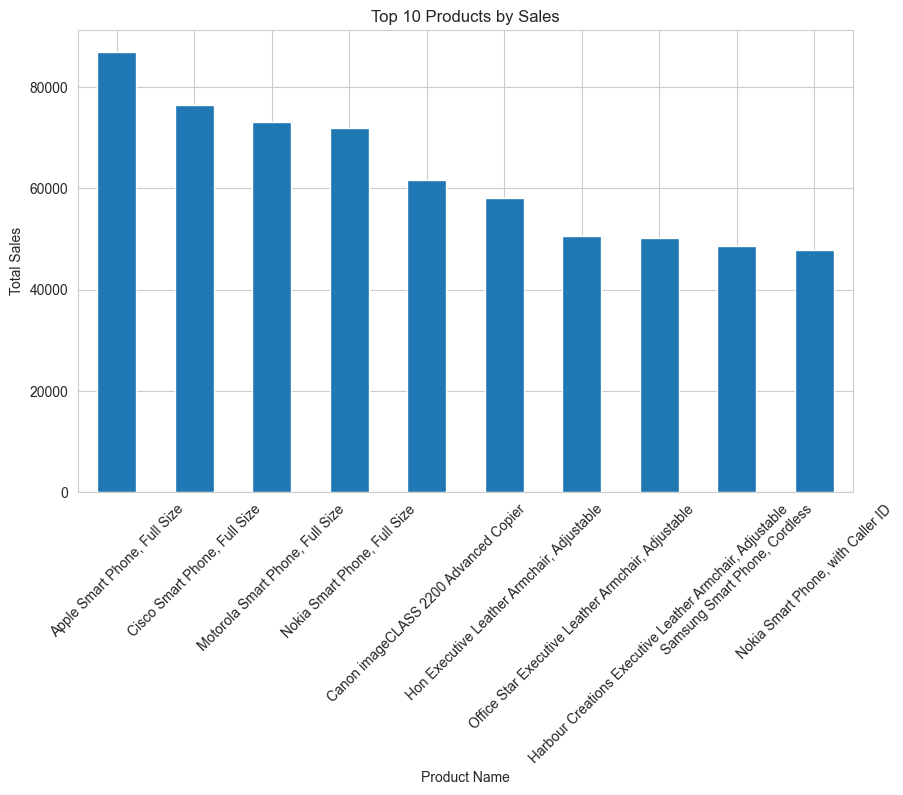

In [14]:
top_products = df.groupby("Product Name")["Sales"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
top_products.plot(kind="bar")

plt.title("Top 10 Products by Sales")
plt.xlabel("Product Name")
plt.ylabel("Total Sales")

plt.xticks(rotation=45)
plt.show()

In [15]:
category_sales = df.groupby("Category")["Sales"].sum().sort_values(ascending=False)

category_sales

Category
Technology         4.744557e+06
Furniture          4.110874e+06
Office Supplies    3.787070e+06
Name: Sales, dtype: float64

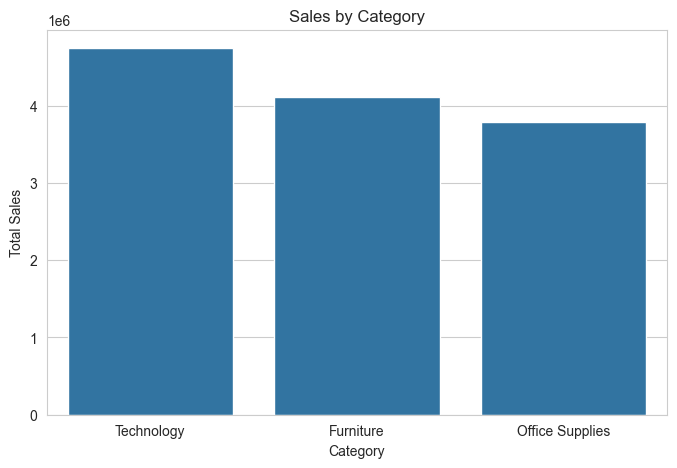

In [16]:
plt.figure(figsize=(8,5))

sns.barplot(x=category_sales.index, y=category_sales.values)

plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")

plt.show()

In [17]:
country_sales = df.groupby("Country")["Sales"].sum().sort_values(ascending=False).head(10)

country_sales

Country
United States     2.297201e+06
Australia         9.252359e+05
France            8.589311e+05
China             7.005620e+05
Germany           6.288400e+05
Mexico            6.225906e+05
India             5.896501e+05
United Kingdom    5.285763e+05
Indonesia         4.048875e+05
Brazil            3.611064e+05
Name: Sales, dtype: float64

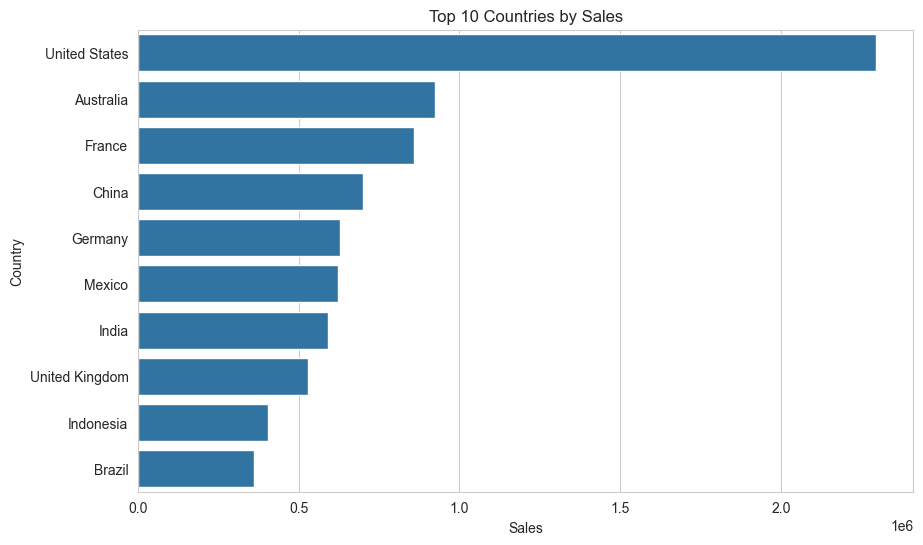

In [18]:
plt.figure(figsize=(10,6))

sns.barplot(x=country_sales.values, y=country_sales.index)

plt.title("Top 10 Countries by Sales")
plt.xlabel("Sales")
plt.ylabel("Country")

plt.show()

In [19]:
df["Order Date"] = pd.to_datetime(df["Order Date"])

C:\Users\USer\AppData\Local\Temp\ipykernel_12716\13081262.py:1: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df["Order Date"] = pd.to_datetime(df["Order Date"])


In [20]:
df["Year"] = df["Order Date"].dt.year
df["Month"] = df["Order Date"].dt.month
df["Month Name"] = df["Order Date"].dt.month_name()

In [21]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'City', 'State', 'Country',
       'Market', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit',
       'Shipping Cost', 'Order Priority', 'Year', 'Month', 'Month Name'],
      dtype='str')

In [22]:
monthly_sales = df.groupby("Month Name")["Sales"].sum()

monthly_sales

Month Name
April        6.985612e+05
August       1.293833e+06
December     1.580781e+06
February     5.437394e+05
January      6.751337e+05
July         7.493818e+05
June         1.269717e+06
March        7.705009e+05
May          9.040123e+05
November     1.551277e+06
October      1.168184e+06
September    1.437380e+06
Name: Sales, dtype: float64

In [23]:
month_order = ["January","February","March","April","May","June",
               "July","August","September","October","November","December"]

monthly_sales = df.groupby("Month Name")["Sales"].sum().reindex(month_order)

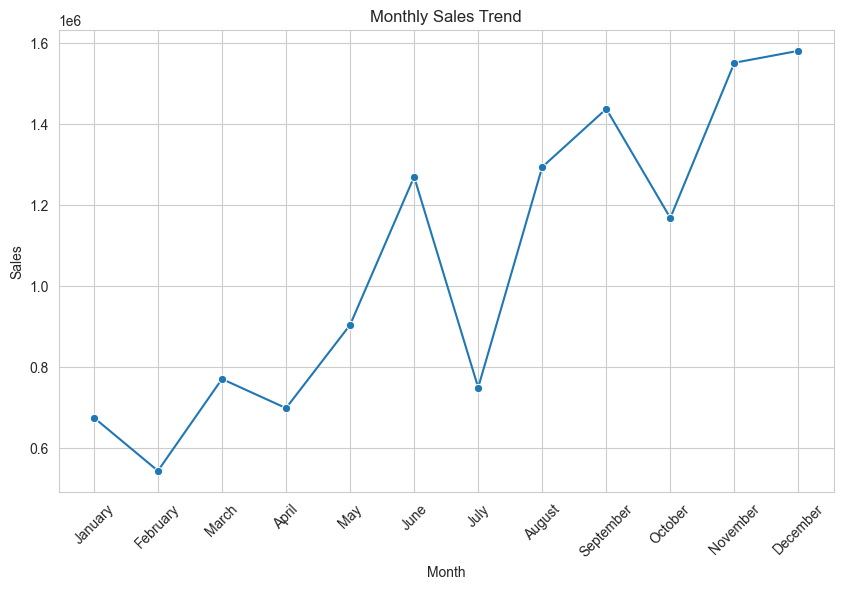

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))

sns.lineplot(x=monthly_sales.index, y=monthly_sales.values, marker="o")

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")

plt.xticks(rotation=45)

plt.show()

In [25]:
import sqlite3

conn = sqlite3.connect("../data/ecommerce.db")

df.to_sql("sales", conn, if_exists="replace", index=False)

print("Database created successfully")

Database created successfully


In [26]:
query = """
SELECT SUM(Sales) AS Total_Revenue
FROM sales
"""

pd.read_sql(query, conn)

,Total_Revenue
0,1.264250e+07


In [27]:
query = """
SELECT "Product Name", SUM(Sales) AS Revenue
FROM sales
GROUP BY "Product Name"
ORDER BY Revenue DESC
LIMIT 10
"""

pd.read_sql(query, conn)

,Product Name,Revenue
0,"Apple Smart Phone, Full Size",86935.7786
1,"Cisco Smart Phone, Full Size",76441.5306
2,"Motorola Smart Phone, Full Size",73156.3030
3,"Nokia Smart Phone, Full Size",71904.5555
4,Canon imageCLASS 2200 Advanced Copier,61599.8240
5,"Hon Executive Leather Armchair, Adjustable",58193.4841
6,"Office Star Executive Leather Armchair, Adjust...",50661.6840
7,"Harbour Creations Executive Leather Armchair, ...",50121.5160
8,"Samsung Smart Phone, Cordless",48653.4600
9,"Nokia Smart Phone, with Caller ID",47877.7857


In [28]:
query = """
SELECT Country, SUM(Sales) AS Revenue
FROM sales
GROUP BY Country
ORDER BY Revenue DESC
"""

pd.read_sql(query, conn)

,Country,Revenue
0,United States,2.297201e+06
1,Australia,9.252359e+05
2,France,8.589311e+05
3,China,7.005620e+05
4,Germany,6.288400e+05
...,...,...
142,Tajikistan,2.427840e+02
143,Macedonia,2.096400e+02
144,Eritrea,1.877400e+02
145,Armenia,1.567500e+02


In [29]:
query = """
SELECT "Month Name", SUM(Sales) AS Revenue
FROM sales
GROUP BY "Month Name"
"""

pd.read_sql(query, conn)

,Month Name,Revenue
0,April,6.985612e+05
1,August,1.293833e+06
2,December,1.580781e+06
3,February,5.437394e+05
4,January,6.751337e+05
5,July,7.493818e+05
6,June,1.269717e+06
7,March,7.705009e+05
8,May,9.040123e+05
9,November,1.551277e+06


In [30]:
top_customers = (
    df.groupby("Customer Name")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_customers

Customer Name
Tom Ashbrook          40488.07080
Tamara Chand          37457.33300
Greg Tran             35550.95428
Christopher Conant    35187.07640
Sean Miller           35170.93296
Bart Watters          32310.44650
Natalie Fritzler      31781.25850
Fred Hopkins          30400.67452
Jane Waco             30288.45030
Hunter Lopez          30243.56658
Name: Sales, dtype: float64

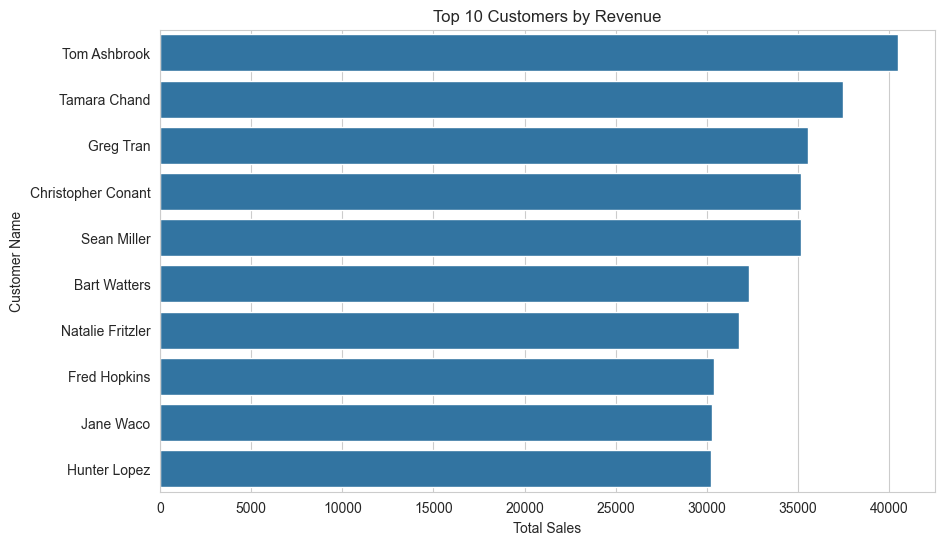

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))

sns.barplot(x=top_customers.values, y=top_customers.index)

plt.title("Top 10 Customers by Revenue")
plt.xlabel("Total Sales")
plt.ylabel("Customer Name")

plt.show()

In [32]:
df["Profit Margin"] = df["Profit"] / df["Sales"]

In [33]:
category_profit = df.groupby("Category")[["Sales","Profit"]].sum()

category_profit["Profit Margin"] = (
    category_profit["Profit"] / category_profit["Sales"]
)

category_profit

,Sales,Profit,Profit Margin
Category,,,
Furniture,4.110874e+06,285204.72380,0.069378
Office Supplies,3.787070e+06,518473.83430,0.136906
Technology,4.744557e+06,663778.73318,0.139903


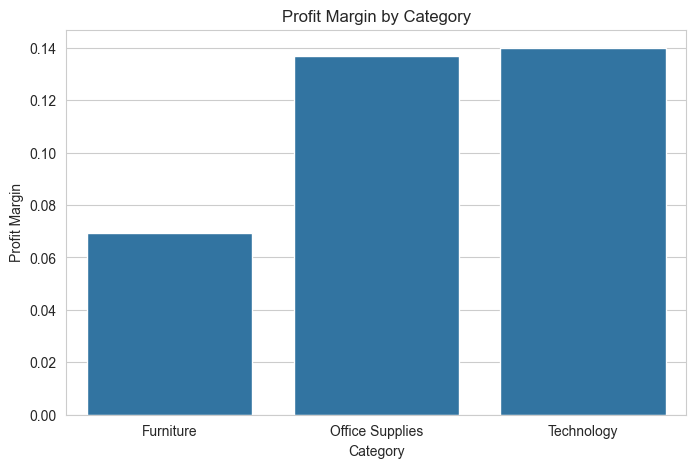

In [34]:
plt.figure(figsize=(8,5))

sns.barplot(x=category_profit.index, y=category_profit["Profit Margin"])

plt.title("Profit Margin by Category")
plt.xlabel("Category")
plt.ylabel("Profit Margin")

plt.show()

In [35]:
region_sales = (
    df.groupby("Region")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

region_sales

Region
Central           2.822303e+06
South             1.600907e+06
North             1.248166e+06
Oceania           1.100185e+06
Southeast Asia    8.844232e+05
North Asia        8.483098e+05
EMEA              8.061613e+05
Africa            7.837732e+05
Central Asia      7.528266e+05
West              7.254578e+05
East              6.787812e+05
Caribbean         3.242809e+05
Canada            6.692817e+04
Name: Sales, dtype: float64

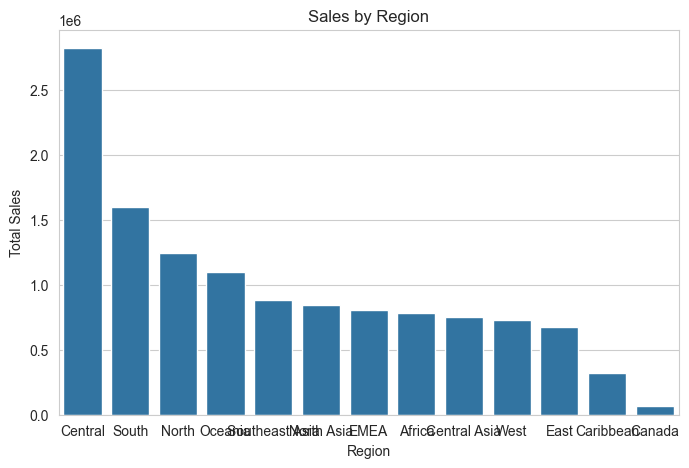

In [36]:
plt.figure(figsize=(8,5))

sns.barplot(x=region_sales.index, y=region_sales.values)

plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Total Sales")

plt.show()

In [37]:
segment_sales = df.groupby("Segment")["Sales"].sum()

segment_sales

Segment
Consumer       6.507949e+06
Corporate      3.824698e+06
Home Office    2.309855e+06
Name: Sales, dtype: float64

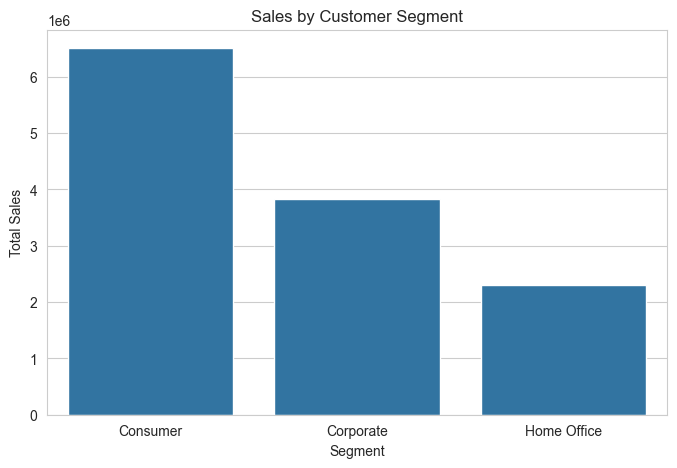

In [38]:
plt.figure(figsize=(8,5))

sns.barplot(x=segment_sales.index, y=segment_sales.values)

plt.title("Sales by Customer Segment")
plt.xlabel("Segment")
plt.ylabel("Total Sales")

plt.show()

In [39]:
top_profit_products = (
    df.groupby("Product Name")["Profit"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_profit_products

Product Name
Canon imageCLASS 2200 Advanced Copier                       25199.9280
Cisco Smart Phone, Full Size                                17238.5206
Motorola Smart Phone, Full Size                             17027.1130
Hoover Stove, Red                                           11807.9690
Sauder Classic Bookcase, Traditional                        10672.0730
Harbour Creations Executive Leather Armchair, Adjustable    10427.3260
Nokia Smart Phone, Full Size                                 9938.1955
Cisco Smart Phone, with Caller ID                            9786.6408
Nokia Smart Phone, with Caller ID                            9465.3257
Belkin Router, USB                                           8955.0180
Name: Profit, dtype: float64

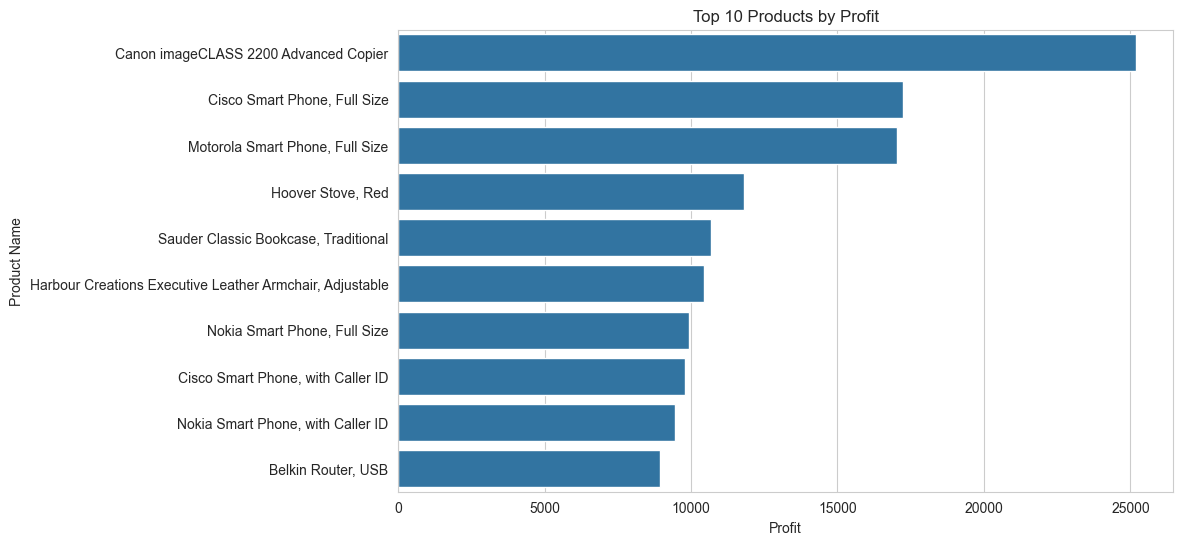

In [40]:
plt.figure(figsize=(10,6))

sns.barplot(x=top_profit_products.values, y=top_profit_products.index)

plt.title("Top 10 Products by Profit")
plt.xlabel("Profit")
plt.ylabel("Product Name")

plt.show()

In [41]:
df["Order Date"] = pd.to_datetime(df["Order Date"])

df["Year"] = df["Order Date"].dt.year
df["Month"] = df["Order Date"].dt.month

In [42]:
sales_heatmap = df.pivot_table(
    values="Sales",
    index="Month",
    columns="Year",
    aggfunc="sum"
)

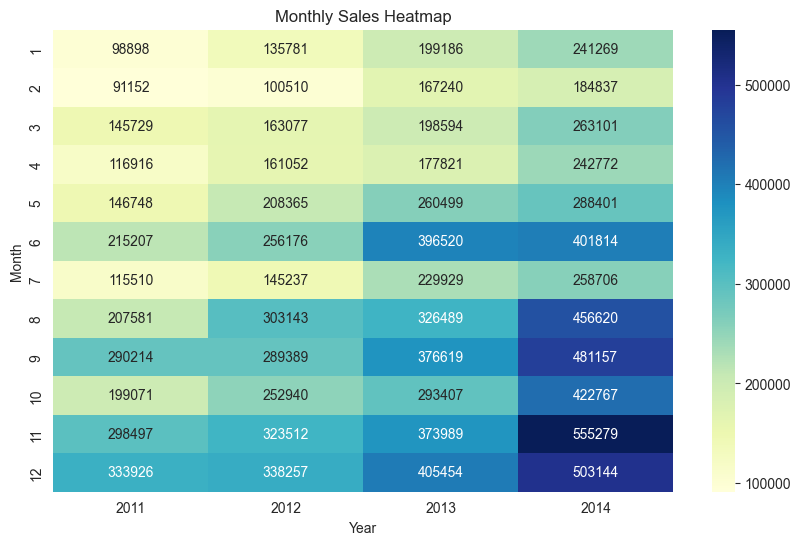

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))

sns.heatmap(
    sales_heatmap,
    cmap="YlGnBu",
    annot=True,
    fmt=".0f"
)

plt.title("Monthly Sales Heatmap")
plt.xlabel("Year")
plt.ylabel("Month")

plt.show()

In [44]:
product_analysis = df.groupby("Product Name")[["Sales","Profit"]].sum()

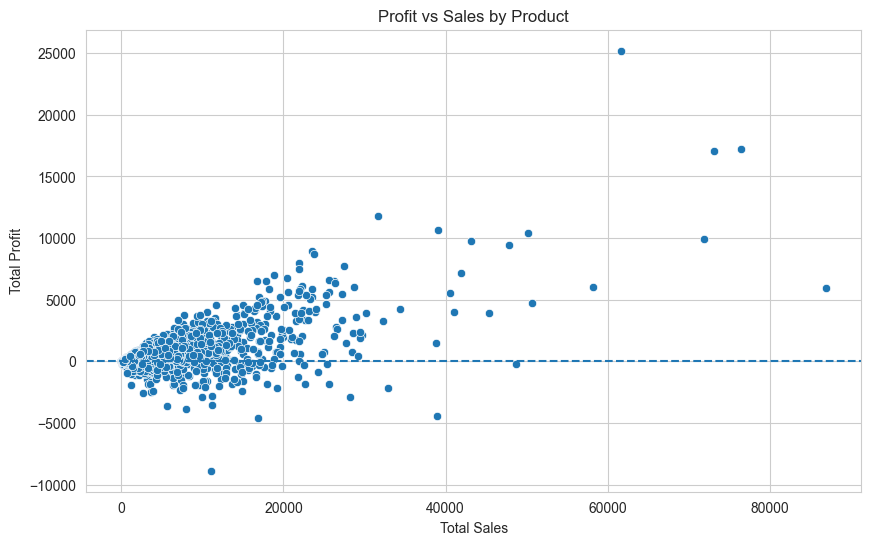

In [45]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=product_analysis,
    x="Sales",
    y="Profit"
)

plt.axhline(0, linestyle="--")

plt.title("Profit vs Sales by Product")
plt.xlabel("Total Sales")
plt.ylabel("Total Profit")

plt.show()

In [46]:
category_sales = df.groupby("Category")["Sales"].sum()

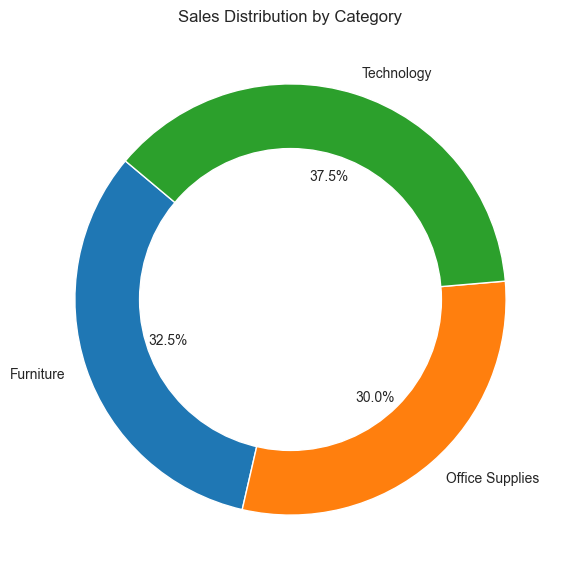

In [47]:
plt.figure(figsize=(7,7))

plt.pie(
    category_sales,
    labels=category_sales.index,
    autopct='%1.1f%%',
    startangle=140
)

centre_circle = plt.Circle((0,0),0.70,fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title("Sales Distribution by Category")

plt.show()

In [48]:
sales_trend = df.groupby("Order Date")["Sales"].sum().reset_index()

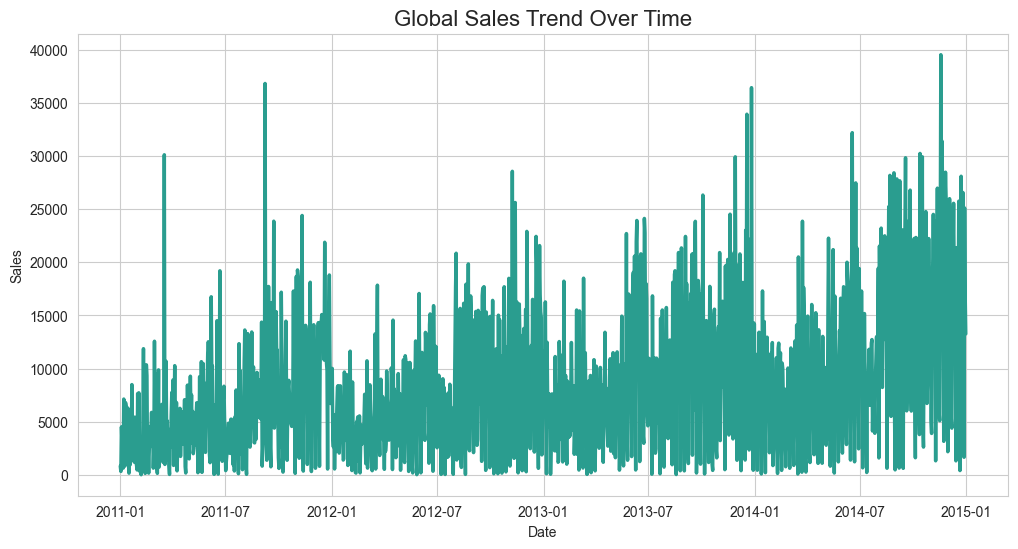

In [49]:
plt.figure(figsize=(12,6))

sns.lineplot(
    data=sales_trend,
    x="Order Date",
    y="Sales",
    color="#2a9d8f",
    linewidth=2.5
)

plt.title("Global Sales Trend Over Time", fontsize=16)
plt.xlabel("Date")
plt.ylabel("Sales")

plt.show()

In [50]:
product_analysis = df.groupby(["Product Name","Category"])[["Sales","Profit"]].sum().reset_index()

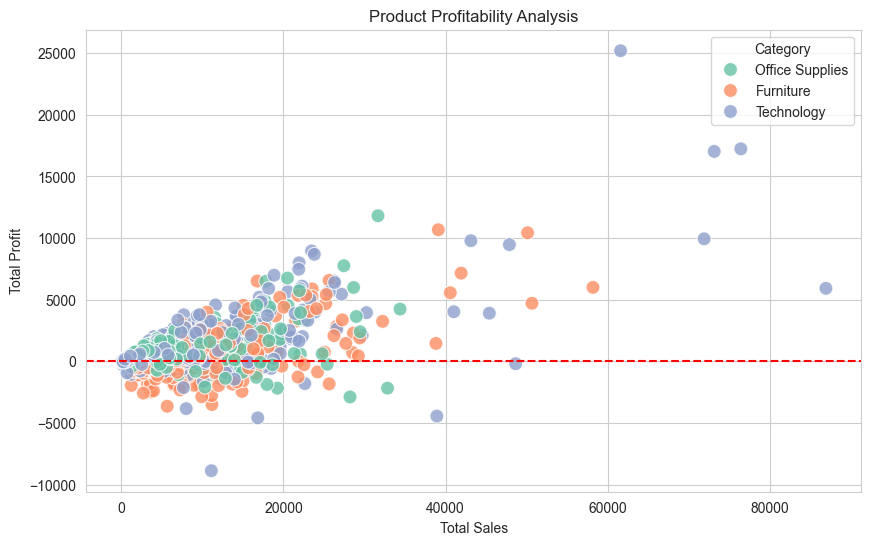

In [51]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=product_analysis,
    x="Sales",
    y="Profit",
    hue="Category",
    palette="Set2",
    s=100,
    alpha=0.8
)

plt.axhline(0, linestyle="--", color="red")

plt.title("Product Profitability Analysis")
plt.xlabel("Total Sales")
plt.ylabel("Total Profit")

plt.show()

In [52]:
top_customers = (
    df.groupby("Customer Name")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

C:\Users\USer\AppData\Local\Temp\ipykernel_12716\3045809784.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


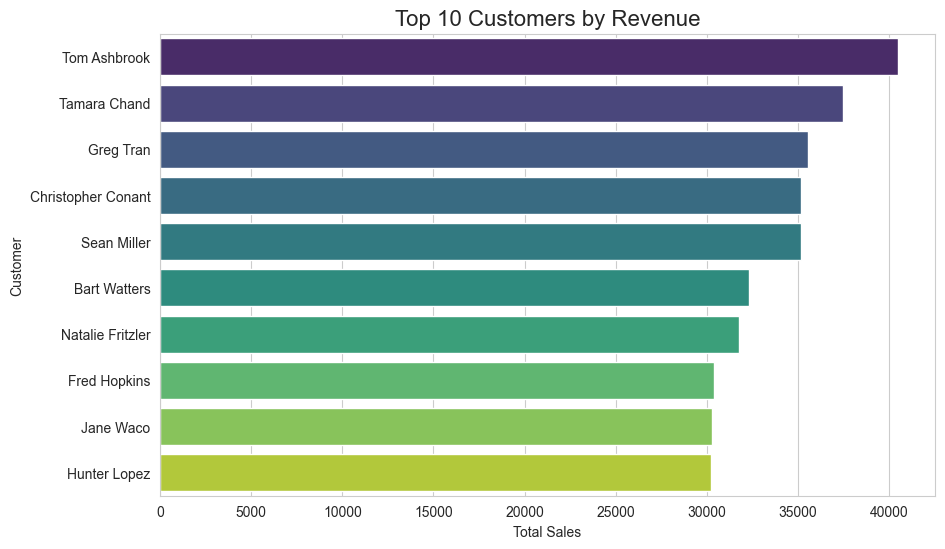

In [53]:
plt.figure(figsize=(10,6))

sns.barplot(
    x=top_customers.values,
    y=top_customers.index,
    palette="viridis"
)

plt.title("Top 10 Customers by Revenue", fontsize=16)
plt.xlabel("Total Sales")
plt.ylabel("Customer")

plt.show()

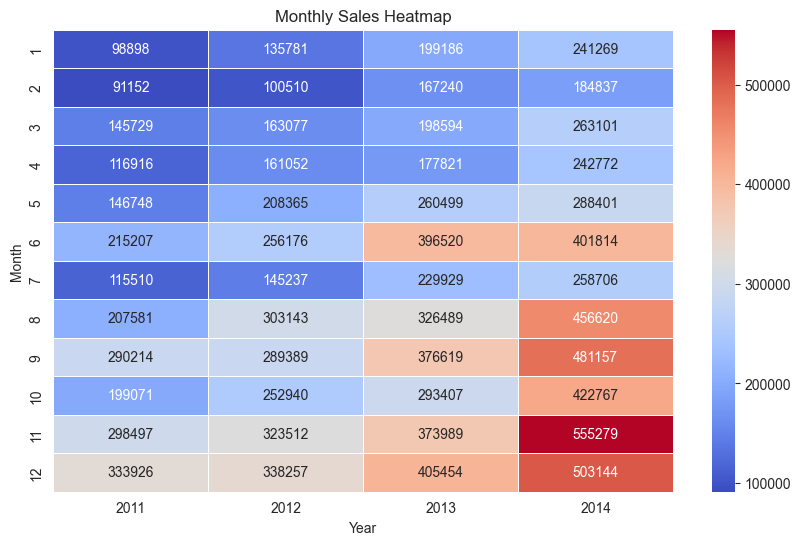

In [54]:
plt.figure(figsize=(10,6))

sns.heatmap(
    sales_heatmap,
    cmap="coolwarm",
    annot=True,
    fmt=".0f",
    linewidths=0.5
)

plt.title("Monthly Sales Heatmap")

plt.show()

In [55]:
pip install squarify

Note: you may need to restart the kernel to use updated packages.


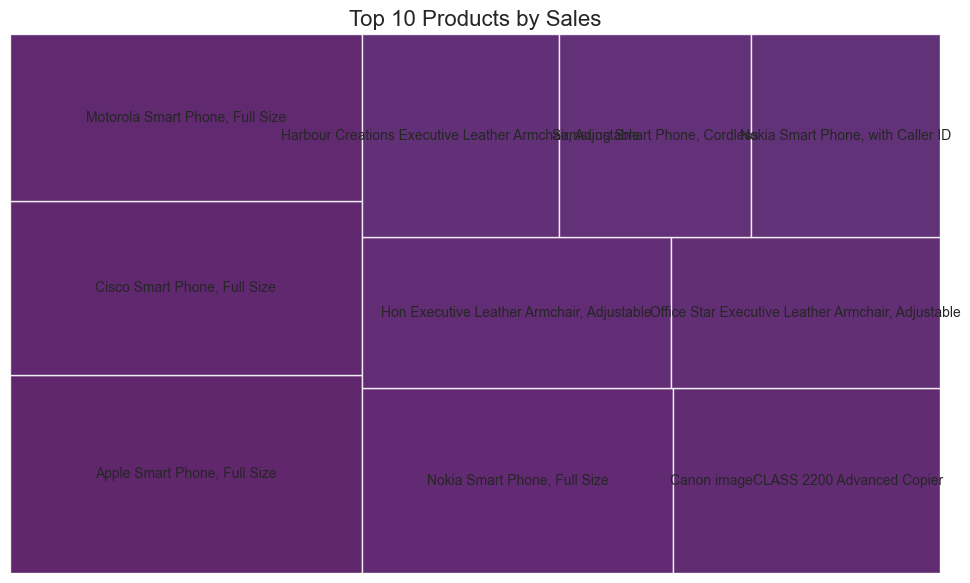

In [56]:
import squarify
import matplotlib.pyplot as plt

top_products = (
    df.groupby("Product Name")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,7))

colors = plt.cm.viridis(range(len(top_products)))

squarify.plot(
    sizes=top_products.values,
    label=top_products.index,
    color=colors,
    alpha=0.85
)

plt.title("Top 10 Products by Sales", fontsize=16)
plt.axis("off")

plt.show()

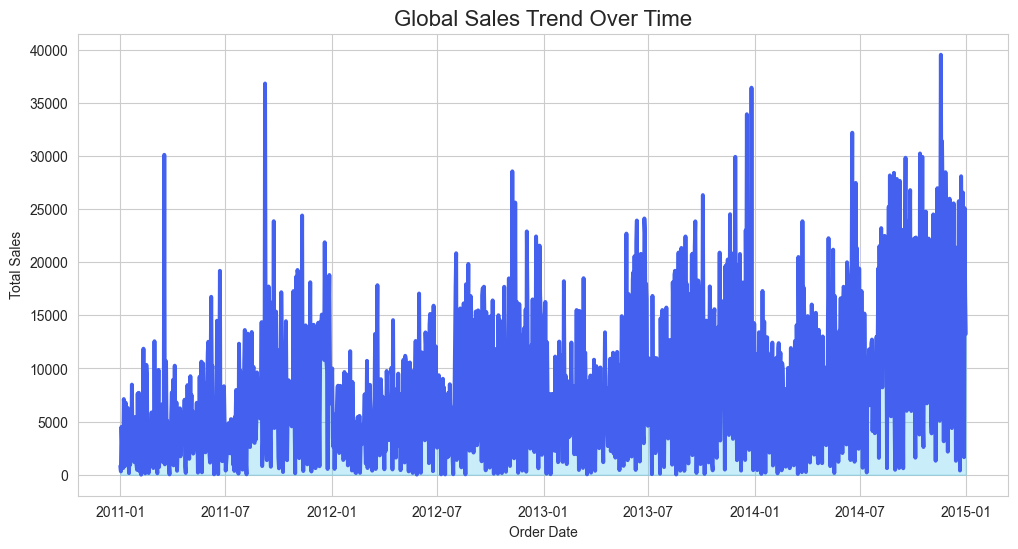

In [57]:
sales_trend = df.groupby("Order Date")["Sales"].sum().reset_index()

plt.figure(figsize=(12,6))

sns.lineplot(
    data=sales_trend,
    x="Order Date",
    y="Sales",
    color="#4361ee",
    linewidth=2.8
)

plt.fill_between(
    sales_trend["Order Date"],
    sales_trend["Sales"],
    color="#4cc9f0",
    alpha=0.3
)

plt.title("Global Sales Trend Over Time", fontsize=16)
plt.xlabel("Order Date")
plt.ylabel("Total Sales")

plt.show()

In [58]:
product_perf = df.groupby("Product Name")[["Sales","Profit"]].sum().reset_index()

In [59]:
avg_sales = product_perf["Sales"].mean()
avg_profit = product_perf["Profit"].mean()

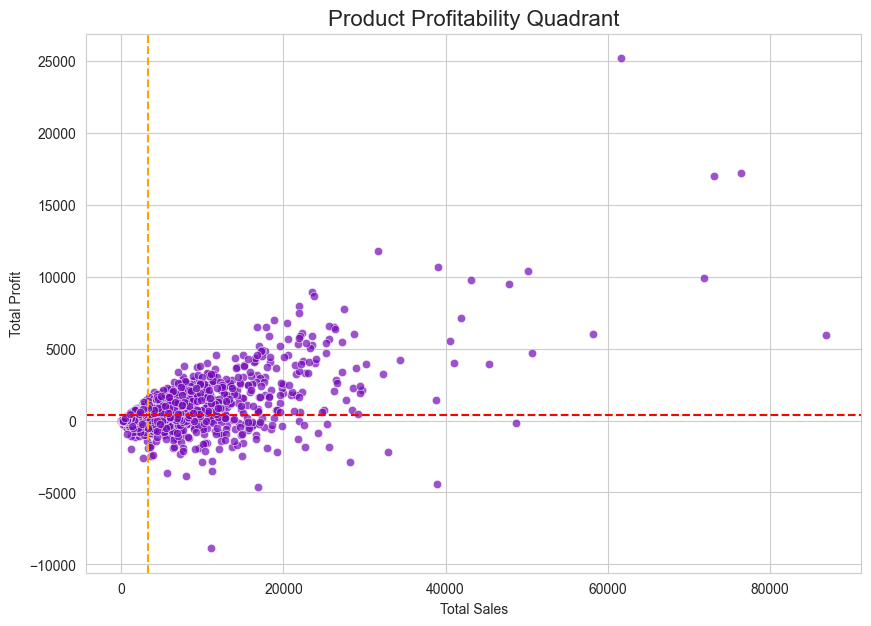

In [60]:
plt.figure(figsize=(10,7))

sns.scatterplot(
    data=product_perf,
    x="Sales",
    y="Profit",
    color="#7209b7",
    alpha=0.7
)

plt.axvline(avg_sales, linestyle="--", color="orange")
plt.axhline(avg_profit, linestyle="--", color="red")

plt.title("Product Profitability Quadrant", fontsize=16)
plt.xlabel("Total Sales")
plt.ylabel("Total Profit")

plt.show()

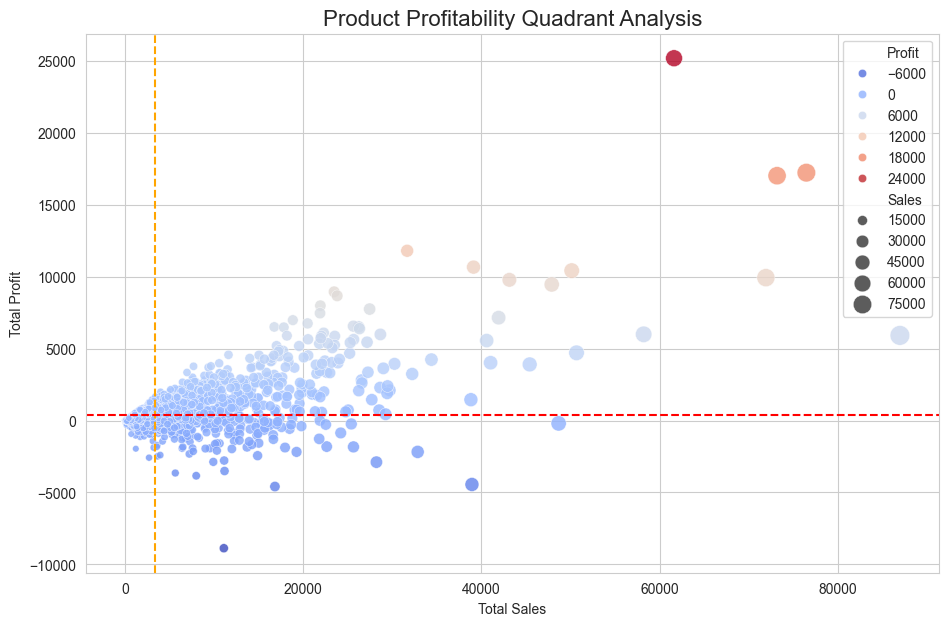

In [61]:
plt.figure(figsize=(11,7))

sns.scatterplot(
    data=product_perf,
    x="Sales",
    y="Profit",
    hue="Profit",
    palette="coolwarm",
    size="Sales",
    sizes=(20,200),
    alpha=0.8
)

plt.axvline(avg_sales, linestyle="--", color="orange")
plt.axhline(avg_profit, linestyle="--", color="red")

plt.title("Product Profitability Quadrant Analysis", fontsize=16)
plt.xlabel("Total Sales")
plt.ylabel("Total Profit")

plt.show()

In [62]:
pip install squarify

Note: you may need to restart the kernel to use updated packages.


In [63]:
category_sales = df.groupby("Category")["Sales"].sum().reset_index()

category_sales

,Category,Sales
0,Furniture,4.110874e+06
1,Office Supplies,3.787070e+06
2,Technology,4.744557e+06


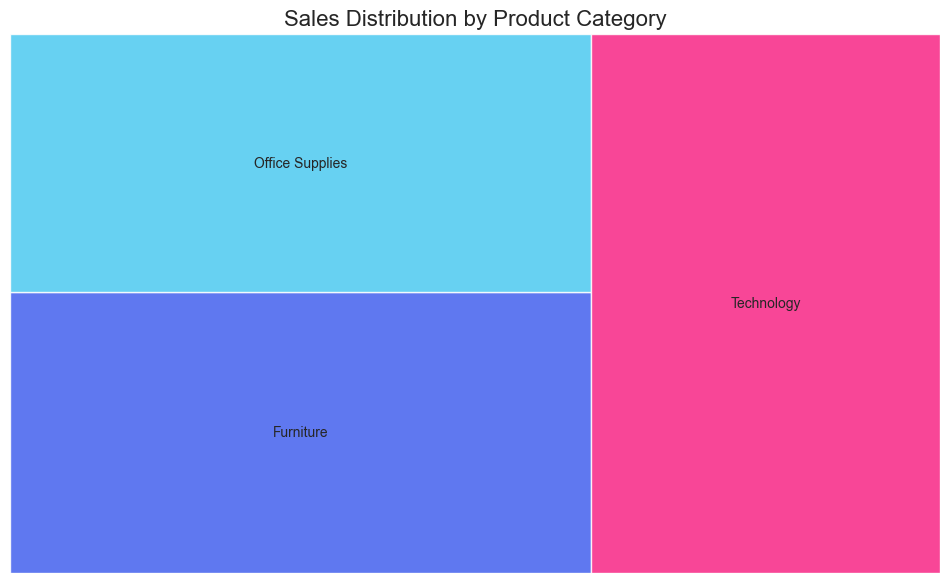

In [64]:
import squarify
import matplotlib.pyplot as plt

plt.figure(figsize=(12,7))

colors = ["#4361ee", "#4cc9f0", "#f72585"]

squarify.plot(
    sizes=category_sales["Sales"],
    label=category_sales["Category"],
    color=colors,
    alpha=0.85
)

plt.title("Sales Distribution by Product Category", fontsize=16)
plt.axis("off")

plt.show()

In [65]:
top_products = (
    df.groupby("Product Name")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(15)
)

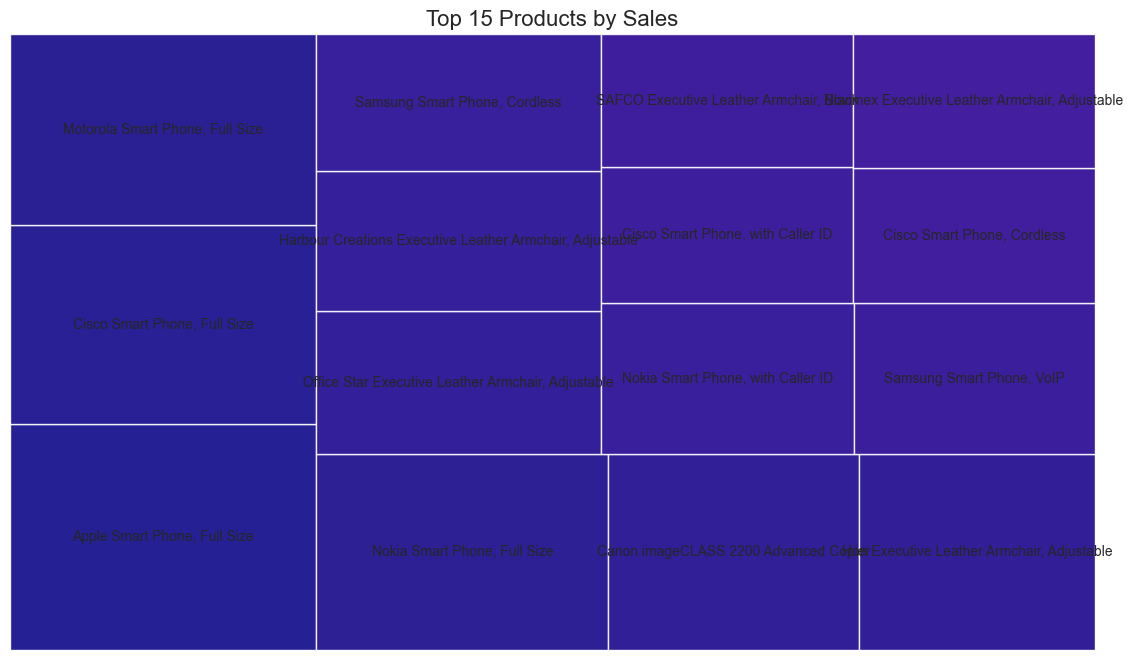

In [66]:
plt.figure(figsize=(14,8))

colors = plt.cm.plasma(range(len(top_products)))

squarify.plot(
    sizes=top_products.values,
    label=top_products.index,
    color=colors,
    alpha=0.9
)

plt.title("Top 15 Products by Sales", fontsize=16)

plt.axis("off")

plt.show()

In [67]:
customer_clv = (
    df.groupby("Customer Name")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

customer_clv.head(10)

,Customer Name,Sales
0,Tom Ashbrook,40488.07080
1,Tamara Chand,37457.33300
2,Greg Tran,35550.95428
3,Christopher Conant,35187.07640
4,Sean Miller,35170.93296
5,Bart Watters,32310.44650
6,Natalie Fritzler,31781.25850
7,Fred Hopkins,30400.67452
8,Jane Waco,30288.45030
9,Hunter Lopez,30243.56658


C:\Users\USer\AppData\Local\Temp\ipykernel_12716\2197960176.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


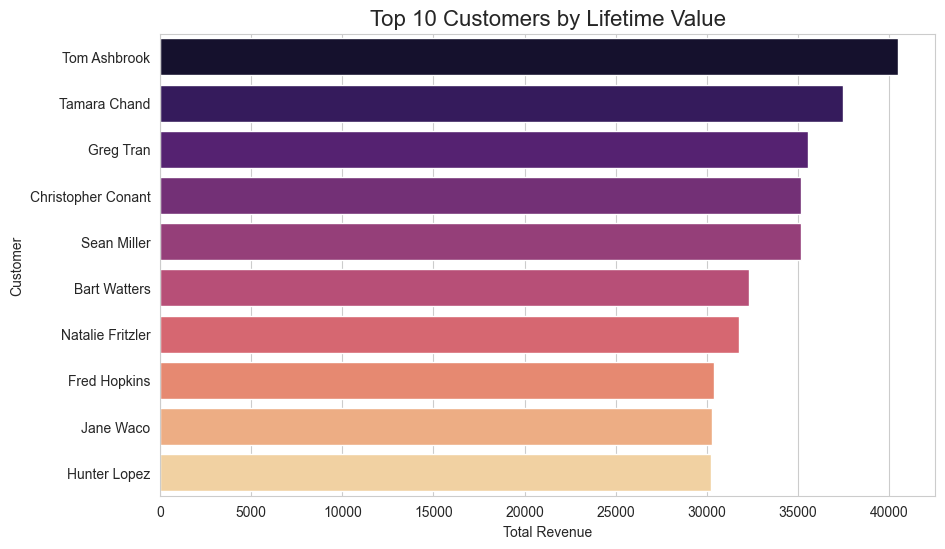

In [68]:
import seaborn as sns
import matplotlib.pyplot as plt

top_clv = customer_clv.head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    data=top_clv,
    x="Sales",
    y="Customer Name",
    palette="magma"
)

plt.title("Top 10 Customers by Lifetime Value", fontsize=16)
plt.xlabel("Total Revenue")
plt.ylabel("Customer")

plt.show()

In [69]:
country_sales = (
    df.groupby("Country")["Sales"]
    .sum()
    .reset_index()
)

country_sales.head()

,Country,Sales
0,Afghanistan,21673.32000
1,Albania,3888.12000
2,Algeria,36091.59000
3,Angola,25554.00000
4,Argentina,57511.78328


In [70]:
import plotly.express as px

fig = px.choropleth(
    country_sales,
    locations="Country",
    locationmode="country names",
    color="Sales",
    color_continuous_scale="Viridis",
    title="Global Sales Distribution"
)

fig.show()

C:\Users\USer\AppData\Local\Temp\ipykernel_12716\1423810303.py:3: DeprecationWarning: The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.
  fig = px.choropleth(


In [71]:
import sqlite3

conn = sqlite3.connect("ecommerce.db")
df.to_sql("sales", conn, if_exists="replace", index=False)

print("Database created successfully!")

Database created successfully!


In [72]:
query = """
SELECT
    "Product Name",
    SUM(Sales) as total_sales
FROM sales
GROUP BY "Product Name"
ORDER BY total_sales DESC
LIMIT 10
"""

import pandas as pd
top_products_sql = pd.read_sql(query, conn)

top_products_sql

,Product Name,total_sales
0,"Apple Smart Phone, Full Size",86935.7786
1,"Cisco Smart Phone, Full Size",76441.5306
2,"Motorola Smart Phone, Full Size",73156.3030
3,"Nokia Smart Phone, Full Size",71904.5555
4,Canon imageCLASS 2200 Advanced Copier,61599.8240
5,"Hon Executive Leather Armchair, Adjustable",58193.4841
6,"Office Star Executive Leather Armchair, Adjust...",50661.6840
7,"Harbour Creations Executive Leather Armchair, ...",50121.5160
8,"Samsung Smart Phone, Cordless",48653.4600
9,"Nokia Smart Phone, with Caller ID",47877.7857


In [73]:
query = """
SELECT
    strftime('%Y-%m', "Order Date") as month,
    SUM(Sales) as total_sales
FROM sales
GROUP BY month
ORDER BY month
"""

monthly_sales_sql = pd.read_sql(query, conn)

monthly_sales_sql

,month,total_sales
0,2011-03,7.705009e+05
1,2011-05,9.040123e+05
2,2011-12,1.580781e+06
3,2012-04,6.985612e+05
4,2012-07,7.493818e+05
5,2012-08,1.293833e+06
6,2013-01,6.751337e+05
7,2013-02,5.437394e+05
8,2013-06,1.269717e+06
9,2013-10,1.168184e+06


In [74]:
query = """
SELECT
    Country,
    SUM(Sales) as total_sales
FROM sales
GROUP BY Country
ORDER BY total_sales DESC
"""

country_sales_sql = pd.read_sql(query, conn)

country_sales_sql

,Country,total_sales
0,United States,2.297201e+06
1,Australia,9.252359e+05
2,France,8.589311e+05
3,China,7.005620e+05
4,Germany,6.288400e+05
...,...,...
142,Tajikistan,2.427840e+02
143,Macedonia,2.096400e+02
144,Eritrea,1.877400e+02
145,Armenia,1.567500e+02


In [75]:
sales_time = df.groupby("Order Date")["Sales"].sum().reset_index()

sales_time["Order Date"] = pd.to_datetime(sales_time["Order Date"])

sales_time = sales_time.set_index("Order Date")

sales_time.head()

,Sales
Order Date,
2011-01-01,808.56300
2011-01-02,314.22000
2011-01-03,4503.53720
2011-01-04,2808.87024
2011-01-05,3662.31000


In [76]:
pip install prophet

   ---------------------------------------- 0.0/12.1 MB ? eta -:--:--
    --------------------------------------- 0.3/12.1 MB ? eta -:--:--
   - -------------------------------------- 0.5/12.1 MB 2.3 MB/s eta 0:00:06
   -- ------------------------------------- 0.8/12.1 MB 1.3 MB/s eta 0:00:09
   --- ------------------------------------ 1.0/12.1 MB 1.4 MB/s eta 0:00:08
   ----- ---------------------------------- 1.6/12.1 MB 1.6 MB/s eta 0:00:07
   ------ --------------------------------- 2.1/12.1 MB 1.7 MB/s eta 0:00:06
   ------- -------------------------------- 2.4/12.1 MB 1.6 MB/s eta 0:00:06
   -------- ------------------------------- 2.6/12.1 MB 1.7 MB/s eta 0:00:06
   ----------- ---------------------------- 3.4/12.1 MB 1.9 MB/s eta 0:00:05
   ------------ --------------------------- 3.9/12.1 MB 1.9 MB/s eta 0:00:05
   --------------- ------------------------ 4.7/12.1 MB 2.1 MB/s eta 0:00:04
   ---------------- ----------------------- 5.0/12.1 MB 2.0 MB/s eta 0:00:04
   ----------

In [77]:
from prophet import Prophet

forecast_df = sales_time.reset_index()

forecast_df.columns = ["ds","y"]

c:\Users\USer\Desktop\global-ecommerce-analytics-dashboard\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [78]:
model = Prophet()

model.fit(forecast_df)

22:11:13 - cmdstanpy - INFO - Chain [1] start processing
22:11:14 - cmdstanpy - INFO - Chain [1] done processing


In [79]:
future = model.make_future_dataframe(periods=180)

forecast = model.predict(future)

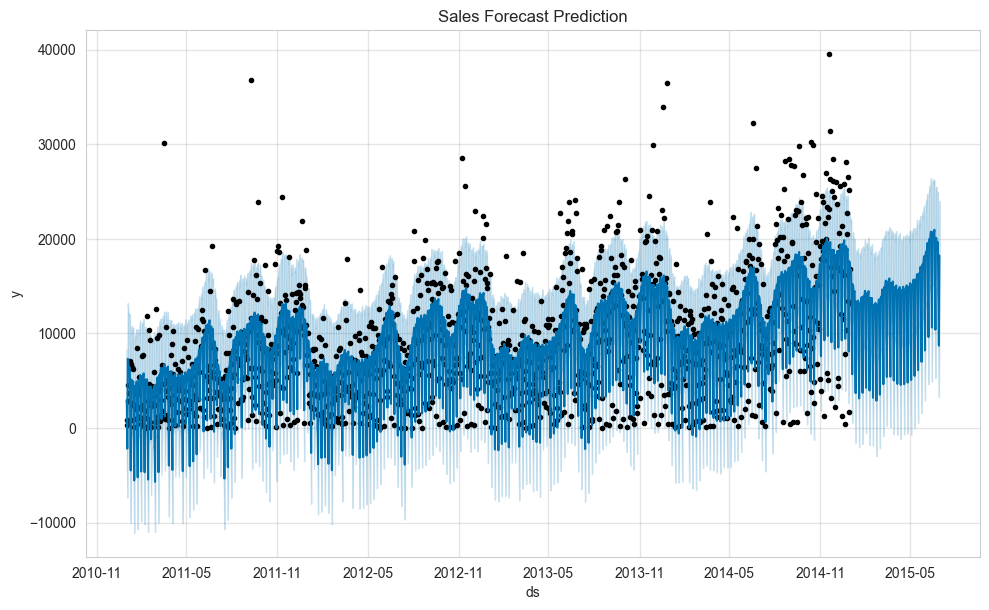

In [80]:
fig = model.plot(forecast)

plt.title("Sales Forecast Prediction")

plt.show()

In [81]:
df.to_csv("../data/processed/final_ecommerce_dataset.csv", index=False)